#########################################
Th = 2971.6164247760266
C = (np.float64(4.699517136695939), np.float64(100.06736974024888))
D = (np.float64(589.3887013955305), np.float64(229.77844868007898))
theta_left = 0.014334478183513097
theta_right = -0.4095563504113293
sag = 27.863999198518286
outer converged = True
inner converged = True
#########################################
maximum sag = 27.863999198518286
x at maximum sag = 298.768758181853
catenary y there = 138.3864758135096
line y there = 166.2504750120279


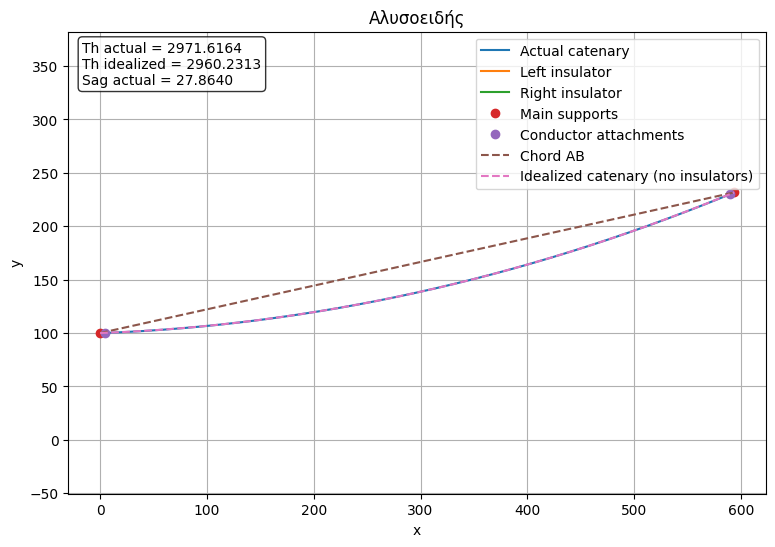

In [6]:
import numpy as np
from matplotlib import pyplot as plt
from catenary import catenary, catenary_length
from line import line_between_points
from sag import catenary_sag_vertical
from plotting import catenary_plot_full
from th_solver import Th_for_target_sag
from attachment_solver import get_attachment_points_for_Th
from span_solver import solve_span_for_target_sag
from plotting import catenary_plot_with_insulators

# Input Constants 
# note: kg = kg-force (essentially)

w = 1.823           #kg/m
G = 75              #kg
L = 4.7             #m
E = 6.18e9          #kg/m2 
diatomi = 5.27      #cm2

# Suspension points
A = (0, 100) 
B = (593.70, 100 + 131.65)    #(144.54, 100-6.64) #

# Example horizontal tension/ target sag
Th = 1000               #kg
target_sag = 27.864      #m  


############### usage ######################



print("#########################################")

result = solve_span_for_target_sag(
    A=A,
    B=B,
    w=w,
    target_sag= target_sag,
    L_left=L,
    L_right=L,
    G_left=G,
    G_right=G,
)

Th = result["Th"]
C = result["C"]
D = result["D"]


print("Th =", result["Th"])
print("C =", result["C"])
print("D =", result["D"])
print("theta_left =", result["theta_left"])
print("theta_right =", result["theta_right"])
print("sag =", result["sag"])
print("outer converged =", result["converged"])
print("inner converged =", result["attachment_converged"])

print("#########################################")

#cat = catenary(A, B, w, Th)
cat = result["catenary"]
lineAB = line_between_points(A, B)
lineCD = line_between_points(C, D)

sag_info = catenary_sag_vertical(cat, lineAB)

print("maximum sag =", sag_info["sag_max"])
print("x at maximum sag =", sag_info["x_sag"])
print("catenary y there =", sag_info["y_curve"])
print("line y there =", sag_info["y_line"])

#catenary_plot_full(cat, lineAB)

catenary_plot_with_insulators(
    cat=result["catenary"],
    A=A,
    B=B,
    C=result["C"],
    D=result["D"],
    show_actual=True,
    show_supports=True,
    show_attachments=True,
    show_chord=True,
    show_low_point=False,
    show_sag=False,
    show_idealized=True,
    show_idealized_sag=False,
    annotate_tensions=True,
    only_idealized=False,
    w=w,
    title="Αλυσοειδής",
)